# OFDM-based Communications with Superimposed Pilots

This notebook provides an implementation of superimposed pilots for OFDM communication systems, based on the approach presented in "[End-to-End Learning for OFDM: From Neural Receivers to Pilotless Communication](https://ieeexplore.ieee.org/abstract/document/9508784)" [1].

We focus specifically on neural network-based receivers that leverage superimposed pilot signals.

## GPU Configuration and Imports

In [ ]:
import os
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import Sionna
try:
    import sionna as sn
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

import numpy as np

# For saving complex Python data structures efficiently
import pickle

# For plotting
%matplotlib inline
import matplotlib.pyplot as plt

# For the implementation of the neural receiver
from tensorflow.keras import Model
from tensorflow.keras.layers import Layer, Conv2D, LayerNormalization
from tensorflow.nn import relu

# Set seed for reproducable results
sn.phy.config.seed = 42

E0000 00:00:1757420801.661313  184956 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757420801.666727  184956 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1757420801.681932  184956 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757420801.681949  184956 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757420801.681950  184956 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757420801.681952  184956 computation_placer.cc:177] computation placer already registered. Please check linka

## Simulation Parameters

In [2]:
# Bit per channel use
NUM_BITS_PER_SYMBOL = 2 # QPSK

# Minimum value of Eb/N0 [dB] for simulations
EBN0_DB_MIN = 0.0

# Maximum value of Eb/N0 [dB] for simulations
EBN0_DB_MAX = 10.0

# How many examples are processed by Sionna in parallel
BATCH_SIZE = 128

# Coding rate
CODERATE = 0.5

# Create an RX-TX association matrix.
# RX_TX_ASSOCIATION[i,j]=1 means that receiver i gets at least one stream
# from transmitter j. Depending on the transmission direction (uplink or downlink),
# the role of UT and BS can change.
# For example, considering a system with 2 RX and 4 TX, the RX-TX
# association matrix could be
# [ [1 , 1, 0, 0],
#   [0 , 0, 1, 1] ]
# which indicates that the RX 0 receives from TX 0 and 1, and RX 1 receives from
# TX 2 and 3.
#
# In this notebook, as we have only a single transmitter and receiver,
# the RX-TX association matrix is simply:
RX_TX_ASSOCIATION = np.array([[1]])

# Instantiate a StreamManagement object
# This determines which data streams are determined for which receiver.
# In this simple setup, this is fairly easy. However, it can get more involved
# for simulations with many transmitters and receivers.
STREAM_MANAGEMENT = sn.phy.mimo.StreamManagement(RX_TX_ASSOCIATION, 1)

# Resource grid configuration without DMRS pilots for superimposed pilot transmission
RESOURCE_GRID_0P = sn.phy.ofdm.ResourceGrid(num_ofdm_symbols=14,
                                            fft_size=76,
                                            subcarrier_spacing=30e3,
                                            num_tx=1,
                                            num_streams_per_tx=1,
                                            cyclic_prefix_length=6)

# Resource grid configuration with two DMRS pilots for baseline comparison
RESOURCE_GRID_2P = sn.phy.ofdm.ResourceGrid(num_ofdm_symbols=14,
                                            fft_size=76,
                                            subcarrier_spacing=30e3,
                                            num_tx=1,
                                            num_streams_per_tx=1,
                                            pilot_pattern="kronecker",
                                            pilot_ofdm_symbol_indices=[2,11],
                                            cyclic_prefix_length=6)

# Carrier frequency in Hz.
CARRIER_FREQUENCY = 2.6e9

# Antenna setting
UT_ARRAY = sn.phy.channel.tr38901.Antenna(polarization="single",
                                          polarization_type="V",
                                          antenna_pattern="omni",
                                          carrier_frequency=CARRIER_FREQUENCY)
BS_ARRAY = sn.phy.channel.tr38901.AntennaArray(num_rows=1,
                                               num_cols=1,
                                               polarization="single",
                                               polarization_type="V",
                                               antenna_pattern="omni",
                                               carrier_frequency=CARRIER_FREQUENCY)

# Nominal delay spread in [s]. Please see the CDL documentation
# about how to choose this value.
DELAY_SPREAD = 100e-9

# The `direction` determines if the UT or BS is transmitting.
# In the `uplink`, the UT is transmitting.
DIRECTION = "uplink"

# Suitable values are ["A", "B", "C", "D", "E"]
CDL_MODEL = "C"

# UT speed [m/s]. BSs are always assumed to be fixed.
# The direction of travel will chosen randomly within the x-y plane.
SPEED = 3.0

# Configure a channel impulse reponse (CIR) generator for the CDL model.
CDL = sn.phy.channel.tr38901.CDL(CDL_MODEL,
                                 DELAY_SPREAD,
                                 CARRIER_FREQUENCY,
                                 UT_ARRAY,
                                 BS_ARRAY,
                                 DIRECTION,
                                 min_speed=SPEED)

Let's inspect the two OFDM resource grids.

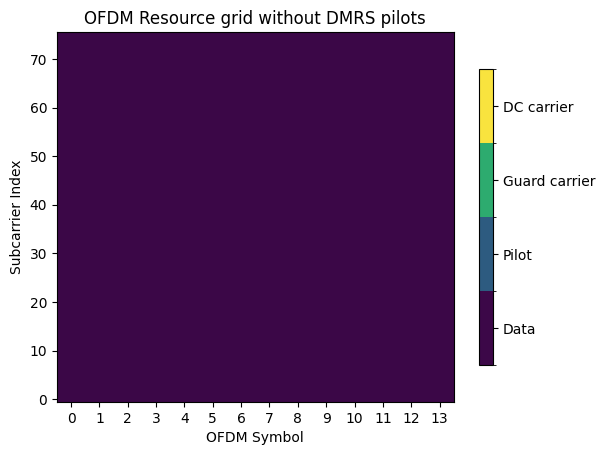

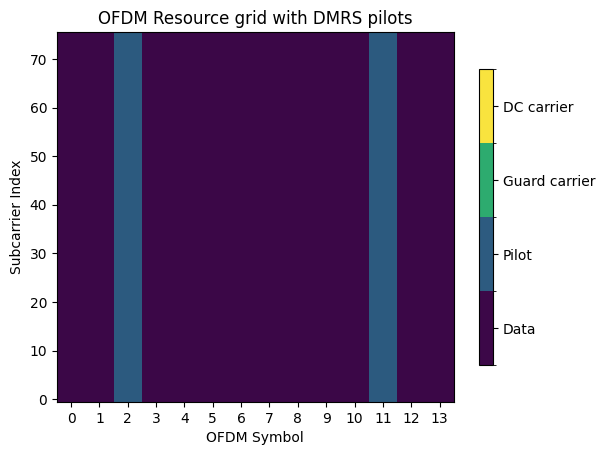

In [3]:
# Resource grid without DMRS pilots
plot = RESOURCE_GRID_0P.show();
plt.title("OFDM Resource grid without DMRS pilots");

# Resource grid with DMRS pilots
plot = RESOURCE_GRID_2P.show();
plt.title("OFDM Resource grid with DMRS pilots");

## Neural Receiver

The next cell defines the Keras layers that implement the neural receiver.
Convolutional layers are leveraged to efficiently process the 2D resource grid that is fed as input to the neural receiver and residual (skip) connections are used to prevent gradient vanishing during training [2].

For convenience, a Keras layer that implements a *residual block* is first defined. The neural receiver is then built by stacking multiple such blocks. The following figure shows the architecture of the neural receiver.

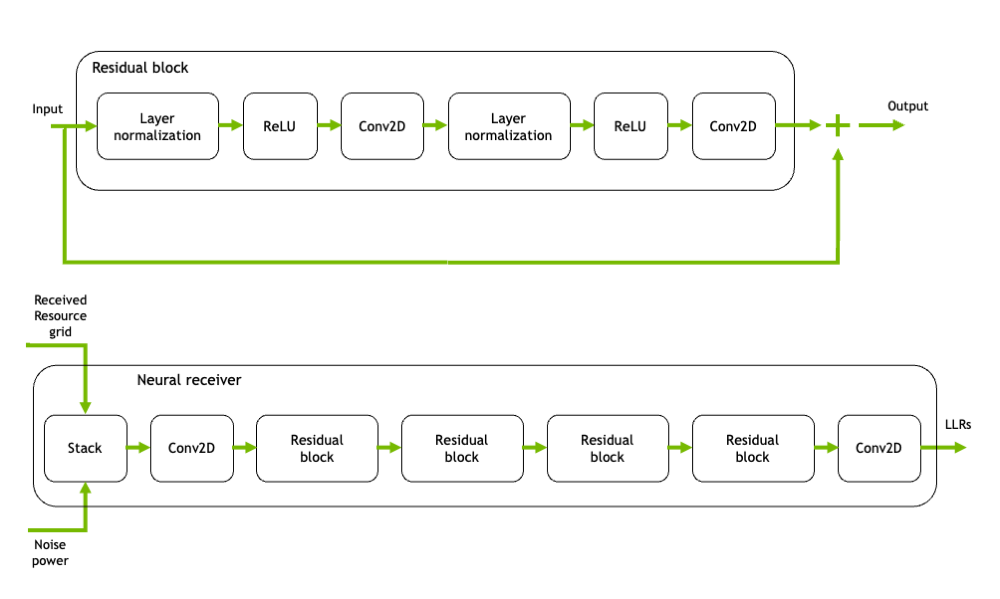

In [4]:
class ResidualBlock(Layer):

    def __init__(self):
        super().__init__()

        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_1 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_1 = Conv2D(filters=128,
                              kernel_size=[3,3],
                              padding='same',
                              activation=None)
        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_2 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_2 = Conv2D(filters=128,
                              kernel_size=[3,3],
                              padding='same',
                              activation=None)

    def call(self, inputs):
        z = self._layer_norm_1(inputs)
        z = relu(z)
        z = self._conv_1(z)
        z = self._layer_norm_2(z)
        z = relu(z)
        z = self._conv_2(z) # [batch size, num time samples, num subcarriers, num_channels]
        # Skip connection
        z = z + inputs

        return z

class NeuralReceiver(Layer):

    def __init__(self):
        super().__init__()

        # Input convolution
        self._input_conv = Conv2D(filters=128,
                                  kernel_size=[3,3],
                                  padding='same',
                                  activation=None)
        # Residual blocks
        self._res_block_1 = ResidualBlock()
        self._res_block_2 = ResidualBlock()
        self._res_block_3 = ResidualBlock()
        self._res_block_4 = ResidualBlock()
        # Output conv
        self._output_conv = Conv2D(filters=NUM_BITS_PER_SYMBOL,
                                   kernel_size=[3,3],
                                   padding='same',
                                   activation=None)

    def call(self, y, no):

        # Assuming a single receiver, remove the num_rx dimension
        y = tf.squeeze(y, axis=1)

        # Feeding the noise power in log10 scale helps with the performance
        no = sn.phy.utils.log10(no)

        # Stacking the real and imaginary components of the different antennas along the 'channel' dimension
        y = tf.transpose(y, [0, 2, 3, 1]) # Putting antenna dimension last
        no = sn.phy.utils.insert_dims(no, 3, 1)
        no = tf.tile(no, [1, y.shape[1], y.shape[2], 1])
        # z : [batch size, num ofdm symbols, num subcarriers, 2*num rx antenna + 1]
        z = tf.concat([tf.math.real(y),
                       tf.math.imag(y),
                       no], axis=-1)
        # Input conv
        z = self._input_conv(z)
        # Residual blocks
        z = self._res_block_1(z)
        z = self._res_block_2(z)
        z = self._res_block_3(z)
        z = self._res_block_4(z)
        # Output conv
        z = self._output_conv(z)

        # Reshape the input to fit what the resource grid demapper is expected
        z = sn.phy.utils.insert_dims(z, 2, 1)

        return z

The following cell defines the end-to-end OFDM system with superimposed pilots.
 
Let $N$ denote the number of subcarriers and $M$ the number of OFDM symbols.
The transmitter implementation follows the architecture shown in the figure below. Coded bits are first mapped to a QAM constellation and then arranged into a resource grid $\mathbf{X}_{\text{d}}$ that *contains only data symbols (no pilots)*.
A separate resource grid that contains fixed QPSK pilot symbols is then *superimposed* onto the data resource grid $\mathbf{X}_{\text{d}}$ according to:

\begin{equation}
\mathbf{X} = \sqrt{1-\alpha} \mathbf{X}_{\text{d}} + \sqrt{\alpha}\mathbf{X}_{\text{p}}
\end{equation}

where $\boldsymbol{\alpha} \in \mathbb{R}^{N \times M}$ is a *trainable* power allocation matrix such that $0 \leq \alpha_{n,m} \leq 1$ for all $n = 1,\ldots,N$ and $m = 1,\ldots,M$. Each element $\alpha_{n,m}$ represents the fraction of energy allocated to pilots at resource element $(n,m)$. The square roots and products in the equation are applied element-wise.

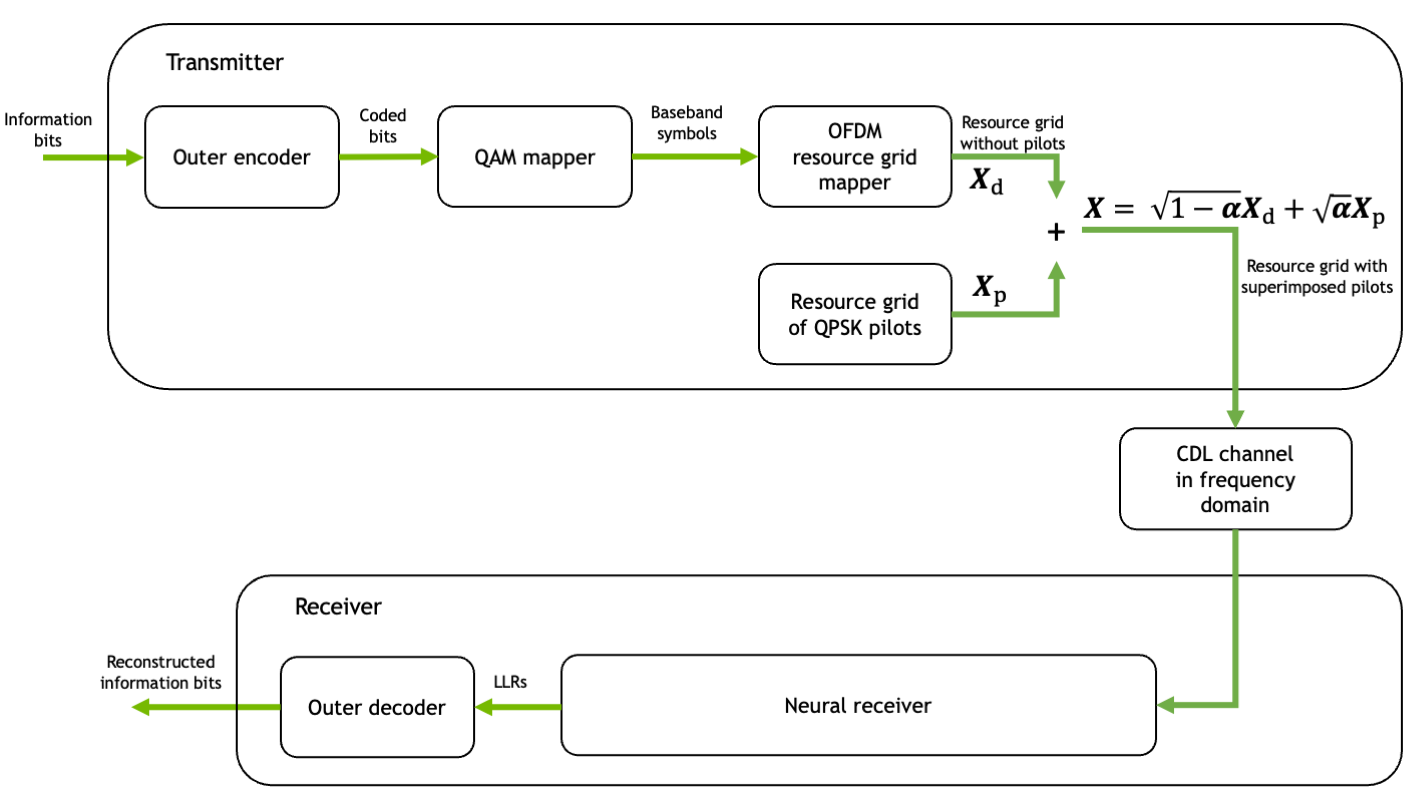

Training of the end-to-end system is done on the bit-metric decoding (BMD) rate [3] which is computed from the transmitted bits and LLRs:

\begin{equation}
R = 1 - \frac{1}{SNMK} \sum_{s = 0}^{S-1} \sum_{n = 0}^{N-1} \sum_{m = 0}^{M-1} \sum_{k = 0}^{K-1} \texttt{BCE} \left( B_{s,n,m,k}, \texttt{LLR}_{s,n,m,k} \right)
\end{equation}

where

* $S$ is the batch size
* $K$ the number of bits per symbol
* $B_{s,n,m,k}$ the $k^{th}$ coded bit transmitted on the resource element $(n,m)$ and for the $s^{th}$ batch example
* $\texttt{LLR}_{s,n,m,k}$ the LLR (logit) computed by the neural receiver corresponding to the $k^{th}$ coded bit transmitted on the resource element $(n,m)$ and for the $s^{th}$ batch example
* $\texttt{BCE} \left( \cdot, \cdot \right)$ the binary cross-entropy in log base 2

Because no outer code is required at training, the outer encoder and decoder are not used at training to reduce computational complexity.

In [5]:
class OFDMSystemNeuralReceiver(Model): # Inherits from Keras Model

    def __init__(self, training):
        super().__init__() # Must call the Keras model initializer

        self.training = training

        n = int(RESOURCE_GRID_0P.num_data_symbols*NUM_BITS_PER_SYMBOL) # Number of coded bits
        k = int(n*CODERATE) # Number of information bits
        self.k = k
        self.n = n

        # The binary source will create batches of information bits
        self.binary_source = sn.phy.mapping.BinarySource()

        # The encoder maps information bits to coded bits
        self.encoder = sn.phy.fec.ldpc.LDPC5GEncoder(k, n)

        # The mapper maps blocks of information bits to constellation symbols
        self.mapper = sn.phy.mapping.Mapper("qam", NUM_BITS_PER_SYMBOL)

        # The resource grid mapper maps symbols onto an OFDM resource grid
        self.rg_mapper = sn.phy.ofdm.ResourceGridMapper(RESOURCE_GRID_0P)

        # Frequency domain channel
        self.channel = sn.phy.channel.OFDMChannel(CDL, RESOURCE_GRID_0P, add_awgn=True, normalize_channel=True, return_channel=False)

        # Neural receiver
        self.neural_receiver = NeuralReceiver()

        # Used to extract data-carrying resource elements frmo the grid of LLRs computed by the neural receiver
        self.rg_demapper = sn.phy.ofdm.ResourceGridDemapper(RESOURCE_GRID_0P, STREAM_MANAGEMENT)

        # The decoder provides hard-decisions on the information bits
        self.decoder = sn.phy.fec.ldpc.LDPC5GDecoder(self.encoder, hard_out=True)

        # Loss function
        self.bce = tf.keras.losses.BinaryCrossentropy(from_logits=True) # Loss function
        
        # A fix and resource grid of superimposed pilots is randomly generated by sampling a QPSK constellation.
        # The seed is set to ensure reproducibility of the pilots.
        # The constellation is centered to ensure no residual DC component, and normalized.
        pilots = sn.phy.mapping.QAMSource(num_bits_per_symbol=2, seed=1)([1, 1, 1, RESOURCE_GRID_0P.num_ofdm_symbols, RESOURCE_GRID_0P.fft_size])
        mean = tf.reduce_mean(pilots)
        pilots = pilots - mean
        pilots = pilots / tf.complex(tf.sqrt(tf.reduce_mean(tf.square(tf.abs(pilots)))), 0.)
        self._pilots = pilots
        
        # Trainable variable that controls the amount of energy allocated to the pilots
        # We train it's logits, i.e., the actual scaling is obtained by applying a sigmoid
        self._scaling_logit = self.add_weight(shape=pilots.shape, initializer="random_normal")

    @tf.function(jit_compile=True) # Graph execution to speed things up
    def __call__(self, batch_size, ebno_db):
        no = sn.phy.utils.ebnodb2no(ebno_db, num_bits_per_symbol=NUM_BITS_PER_SYMBOL, coderate=CODERATE, resource_grid=RESOURCE_GRID_0P)

        # The neural receiver is expected no to have shape [batch_size].
        if len(no.shape) == 0:
            no = tf.fill([batch_size], no)

        # Transmitter
        # Outer coding is only performed if not training
        if self.training:
            codewords = self.binary_source([batch_size, 1, 1, self.n])
        else:
            bits = self.binary_source([batch_size, 1, 1, self.k])
            codewords = self.encoder(bits)
        # Map data to constellation symbols
        x = self.mapper(codewords)
        # Map symbols to resource grid
        x_data = self.rg_mapper(x)
        # Add superimposed pilots
        scaling = tf.nn.sigmoid(self._scaling_logit)
        scaling = tf.complex(scaling, 0.)
        x_rg = tf.sqrt(1.-scaling)*x_data + tf.sqrt(scaling)*self._pilots

        # Channel
        y = self.channel(x_rg, no)

        # Receiver
        llr = self.neural_receiver(y, no)
        llr = self.rg_demapper(llr) # Extract data-carrying resource elements. The other LLrs are discarded
        llr = tf.reshape(llr, [batch_size, 1, 1, self.n]) # Reshape the LLRs to fit what the outer decoder is expected
        if self.training:
            loss = self.bce(codewords, llr)
            return loss
        else:
            bits_hat = self.decoder(llr)
            return bits, bits_hat

## Training

The following cell implements a training loop that performs stochastic gradient descent (SGD) optimization.

Each training iteration consists of:
- Sampling a batch of signal-to-noise ratios $E_b/N_0$, where $E_b$ is the energy per bit and $N_0$ is the noise variance
- Executing a forward pass through the end-to-end system within a gradient tape context
- Computing gradients using automatic differentiation and applying them via the Adam optimizer
- Periodically displaying the current BMD rate to monitor training progress
 
Upon completion, the trained model weights are saved to a file for later use.
 
**Note:** Training may require significant computational time. For convenience, [pre-trained weights are available for download](https://drive.google.com/drive/folders/14KSkSXvAhVB5rGAivHIlsYzq0hH7Anxm?usp=sharing). Skip executing the next cell if you prefer to use the pre-trained model instead of training from scratch.

In [ ]:
# Instantiating the end-to-end model for training
model = OFDMSystemNeuralReceiver(training=True)

# Number of iterations used for training
NUM_TRAINING_ITERATIONS = 5000

# Adam optimizer (SGD variant)
optimizer = tf.keras.optimizers.Adam()

# Training loop
for i in range(NUM_TRAINING_ITERATIONS):
    # Sample a batch of SNRs.
    ebno_db = tf.random.uniform(shape=[BATCH_SIZE], minval=EBN0_DB_MIN, maxval=EBN0_DB_MAX)
    # Forward pass
    with tf.GradientTape() as tape:
        loss = model(BATCH_SIZE, ebno_db)
    # Computing and applying gradients
    weights = model.trainable_weights
    grads = tape.gradient(loss, weights)
    optimizer.apply_gradients(zip(grads, weights))
    # Print progress
    if i % 100 == 0:
        print(f"{i}/{NUM_TRAINING_ITERATIONS}  Loss: {loss:.2E}", end="\r")

# Save the weights in a file
weights = model.get_weights()
with open('weights-ofdm-sip', 'wb') as f:
    pickle.dump(weights, f)

## Evaluation of the End-to-end System with Superimposed Pilots

The next cell implements two baseline systems for comparison: one that assumes perfect knowledge of the channel coefficients, and another that uses least-squares (LS) channel estimation. Both systems employ linear minimum mean square error (LMMSE) equalization with "app" (a posteriori probability) demapping.

In [6]:
class OFDMSystem(Model): # Inherits from Keras Model

    def __init__(self, perfect_csi):
        super().__init__() # Must call the Keras model initializer

        self.perfect_csi = perfect_csi

        n = int(RESOURCE_GRID_2P.num_data_symbols*NUM_BITS_PER_SYMBOL) # Number of coded bits
        k = int(n*CODERATE) # Number of information bits
        self.k = k

        # The binary source will create batches of information bits
        self.binary_source = sn.phy.mapping.BinarySource()

        # The encoder maps information bits to coded bits
        self.encoder = sn.phy.fec.ldpc.LDPC5GEncoder(k, n)

        # The mapper maps blocks of information bits to constellation symbols
        self.mapper = sn.phy.mapping.Mapper("qam", NUM_BITS_PER_SYMBOL)

        # The resource grid mapper maps symbols onto an OFDM resource grid
        self.rg_mapper = sn.phy.ofdm.ResourceGridMapper(RESOURCE_GRID_2P)

        # Frequency domain channel
        self.channel = sn.phy.channel.OFDMChannel(CDL, RESOURCE_GRID_2P, add_awgn=True, normalize_channel=True, return_channel=True)

        # The LS channel estimator will provide channel estimates and error variances
        self.ls_est = sn.phy.ofdm.LSChannelEstimator(RESOURCE_GRID_2P, interpolation_type="nn")

        # The LMMSE equalizer will provide soft symbols together with noise variance estimates
        self.lmmse_equ = sn.phy.ofdm.LMMSEEqualizer(RESOURCE_GRID_2P, STREAM_MANAGEMENT)

        # The demapper produces LLR for all coded bits
        self.demapper = sn.phy.mapping.Demapper("app", "qam", NUM_BITS_PER_SYMBOL)

        # The decoder provides hard-decisions on the information bits
        self.decoder = sn.phy.fec.ldpc.LDPC5GDecoder(self.encoder, hard_out=True)

    @tf.function(jit_compile=True) # Graph execution to speed things up
    def __call__(self, batch_size, ebno_db):
        no = sn.phy.utils.ebnodb2no(ebno_db, num_bits_per_symbol=NUM_BITS_PER_SYMBOL, coderate=CODERATE, resource_grid=RESOURCE_GRID_2P)

        # Transmitter
        bits = self.binary_source([batch_size, 1, RESOURCE_GRID_2P.num_streams_per_tx, self.k])
        codewords = self.encoder(bits)
        x = self.mapper(codewords)
        x_rg = self.rg_mapper(x)

        # Channel
        y, h_freq = self.channel(x_rg, no)

        # Receiver
        if self.perfect_csi:
            h_hat, err_var = h_freq, 0.
        else:
            h_hat, err_var = self.ls_est (y, no)
        x_hat, no_eff = self.lmmse_equ(y, h_hat, err_var, no)
        llr = self.demapper(x_hat, no_eff)
        bits_hat = self.decoder(llr)

        return bits, bits_hat

In [7]:
ber_plots = sn.phy.utils.PlotBER("Advanced neural receiver")

baseline_ls = OFDMSystem(False)
ber_plots.simulate(baseline_ls,
                  ebno_dbs=np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 20),
                  batch_size=BATCH_SIZE,
                  num_target_block_errors=100, # simulate until 100 block errors occured
                  legend="Baseline: LS Estimation",
                  soft_estimates=True,
                  max_mc_iter=100, # run 100 Monte-Carlo simulations (each with batch_size samples)
                  show_fig=False);

baseline_pcsi = OFDMSystem(True)
ber_plots.simulate(baseline_pcsi,
                  ebno_dbs=np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 20),
                  batch_size=BATCH_SIZE,
                  num_target_block_errors=100, # simulate until 100 block errors occured
                  legend="Baseline: Perfect CSI",
                  soft_estimates=True,
                  max_mc_iter=100, # run 100 Monte-Carlo simulations (each with batch_size samples)
                  show_fig=False);

I0000 00:00:1757420830.320715  184956 service.cc:152] XLA service 0x44469050 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757420830.320745  184956 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
I0000 00:00:1757420832.130328  184956 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1757420840.740910  184956 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 3.4612e-01 | 1.0000e+00 |       40405 |      116736 |          128 |         128 |        15.5 |reached target block errors
    0.526 | 3.3227e-01 | 1.0000e+00 |       38788 |      116736 |          128 |         128 |         0.0 |reached target block errors
    1.053 | 3.2133e-01 | 1.0000e+00 |       37511 |      116736 |          128 |         128 |         0.0 |reached target block errors
    1.579 | 3.0139e-01 | 1.0000e+00 |       35183 |      116736 |          128 |         128 |         0.0 |reached target block errors
    2.105 | 2.8698e-01 | 1.0000e+00 |       33501 |      116736 |          128 |         128 |         0.0 |reached target block errors
    2.632 | 2.6740e-01 | 1.0000e+00 |       31215 |      116736 |

Next, we instantiate the end-to-end system with the neural receiver and evaluate its performance. We also visualize the learned energy allocation matrix $\mathbf{\alpha}$ by comparing it before and after training. The initial matrix represents random initialization, while the trained matrix shows the optimized energy distribution between pilots and data.

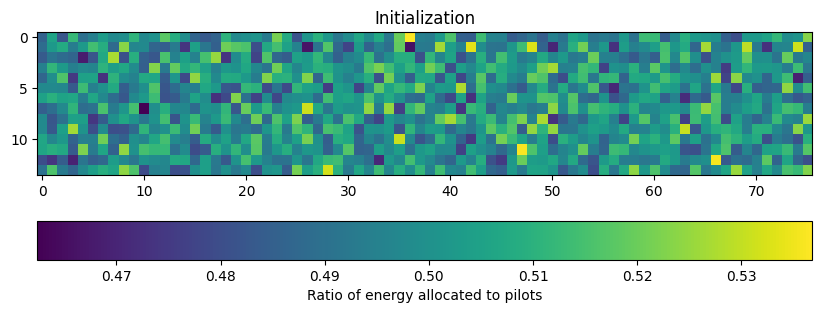

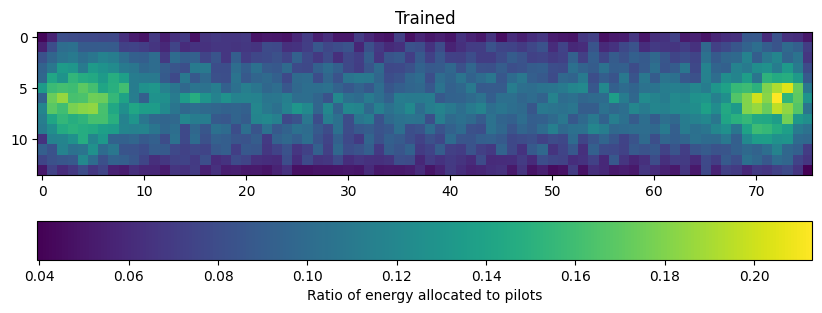

In [8]:
# Instantiating the end-to-end model for evaluation
model = OFDMSystemNeuralReceiver(training=False)

plt.figure(figsize=(10, 4))
plt.imshow(tf.nn.sigmoid(model._scaling_logit[0,0,0].numpy()))
plt.colorbar(label="Ratio of energy allocated to pilots", orientation="horizontal")
plt.title("Initialization")

# Run one inference to build the layers and loading the weights
model(tf.constant(1, tf.int32), tf.constant(10.0, tf.float32))
with open('weights-ofdm-sip', 'rb') as f:
    weights = pickle.load(f)
    model.set_weights(weights)
    
plt.figure(figsize=(10, 4))
plt.imshow(tf.nn.sigmoid(model._scaling_logit[0,0,0].numpy()))
plt.colorbar(label="Ratio of energy allocated to pilots", orientation="horizontal")
plt.title("Trained");

Finally, we evaluate the performance of our end-to-end system with superimposed pilots and the neural receiver and visualize the bit error rate (BER) curves.

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.4775e-01 | 1.0000e+00 |       33741 |      136192 |          128 |         128 |        10.6 |reached target block errors
    0.526 | 2.2479e-01 | 1.0000e+00 |       30615 |      136192 |          128 |         128 |         0.0 |reached target block errors
    1.053 | 2.0511e-01 | 1.0000e+00 |       27934 |      136192 |          128 |         128 |         0.0 |reached target block errors
    1.579 | 1.6602e-01 | 1.0000e+00 |       22610 |      136192 |          128 |         128 |         0.0 |reached target block errors
    2.105 | 1.0429e-01 | 8.2031e-01 |       14204 |      136192 |          105 |         128 |         0.0 |reached target block errors
    2.632 | 5.5506e-02 | 5.0781e-01 |       15119 |      272384 |

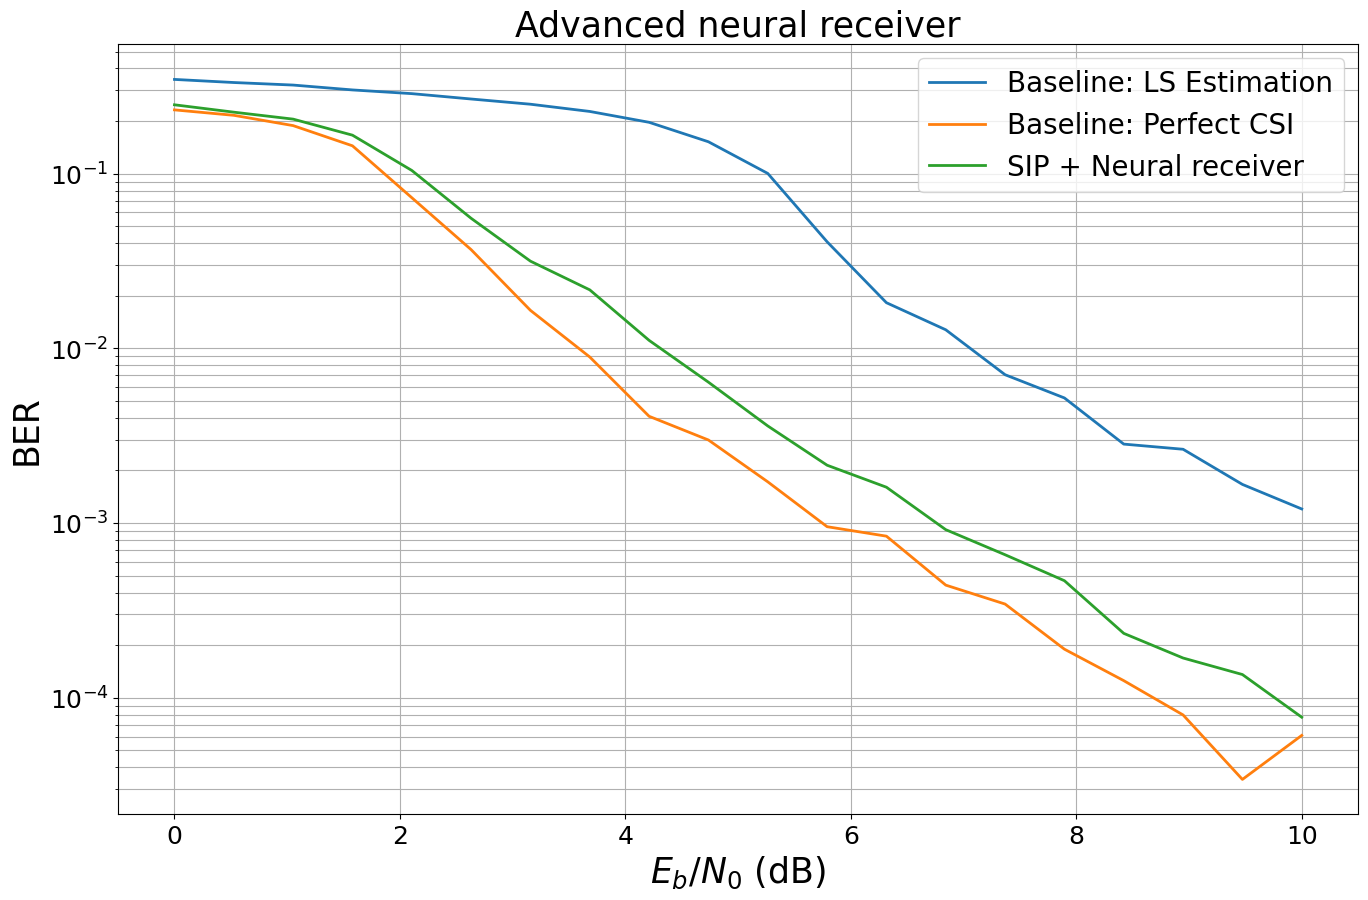

In [10]:
# Computing and plotting BER
ber_plots.simulate(model,
                   ebno_dbs=np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 20),
                   batch_size=BATCH_SIZE,
                   num_target_block_errors=100,
                   legend="SIP + Neural receiver",
                   soft_estimates=True,
                   max_mc_iter=100,
                   show_fig=True);

## References

[1] F. Ait Aoudia and J. Hoydis, "End-to-end Learning for OFDM: From Neural Receivers to Pilotless Communication," in IEEE Transactions on Wireless Communications, doi: 10.1109/TWC.2021.3101364.

[2] M. Honkala, D. Korpi and J. M. J. Huttunen, "DeepRx: Fully Convolutional Deep Learning Receiver," in IEEE Transactions on Wireless Communications, vol. 20, no. 6, pp. 3925-3940, June 2021, doi: 10.1109/TWC.2021.3054520.

[3] G. Böcherer, "Achievable Rates for Probabilistic Shaping", arXiv:1707.01134, 2017.